## Thực hành 1: Khai thác dataset thực tế

In [1]:
#import thư viện
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

### Tổng quan về Bộ dữ liệu AI4I 2020 Predictive Maintenance
- Bộ dữ liệu AI4I 2020 Predictive Maintenance Dataset (Bảo trì dự đoán AI4I 2020) được thiết kế bởi tác giả Stephan Matzka và công bố tại Viện Nghiên cứu Trí tuệ Nhân tạo về Công nghiệp (AI4I). Đây là một tập dữ liệu chuẩn hóa (synthetic dataset) mô phỏng lại các kịch bản vận hành thực tế của máy móc thiết bị trong một nhà máy sản xuất công nghiệp.
Mục tiêu cốt lõi của bộ dữ liệu này là giúp các kỹ sư và nhà khoa học dữ liệu xây dựng, thử nghiệm các mô hình học máy (Machine Learning) nhằm dự đoán trước thời điểm thiết bị sẽ bị hỏng hóc (Predictive Maintenance) dựa trên các tín hiệu cảm biến.
------------------------------
### Cấu trúc và Ý nghĩa các Cột Thuộc tính
Bộ dữ liệu gồm có 10.000 dòng (mẫu thử) và 14 cột dữ liệu, được chia thành các nhóm thông tin chính sau đây:
### 1. Nhóm thông tin định danh và Phân loại

* UDI: Số thứ tự định danh duy nhất cho từng bản ghi dữ liệu (từ 1 đến 10.000).
* Product ID: Mã định danh của sản phẩm, bắt đầu bằng ký tự đại diện cho loại máy.
* Type: Phân loại chất lượng của dòng máy vận hành, gồm 3 cấp độ:
   * L (Low): Dòng máy phổ thông, chiếm phần lớn dữ liệu (60%), có tỷ lệ hỏng hóc cao hơn.
   * M (Medium): Dòng máy trung cấp (chiếm 30%).
   * H (High): Dòng máy cao cấp (chiếm 10%), được chế tạo với tiêu chuẩn khắt khe, ít hỏng hóc hơn.

### 2. Nhóm thông số kỹ thuật (Dữ liệu từ cảm biến)

* Air temperature [K]: Nhiệt độ không khí/môi trường xung quanh nhà máy tính theo độ Kelvin (°K).
* Process temperature [K]: Nhiệt độ của chính quy trình sản xuất bên trong máy tính theo độ Kelvin (°K).
* Rotational speed [rpm]: Tốc độ quay của trục máy, tính bằng số vòng trên phút (rpm).
* Torque [Nm]: Lực xoắn tác động lên trục máy, tính bằng đơn vị Newton-mét (Nm).
* Tool wear [min]: Thời gian mài mòn của công cụ cắt/gọt trong quá trình gia công, tính theo số phút.

### 3. Cột mục tiêu (Target) để dự đoán

* Machine failure: Trạng thái hỏng máy. Cột này nhận giá trị 0 nếu máy chạy bình thường và 1 nếu xảy ra sự cố hỏng hóc tại thời điểm đó.

### 4. Nhóm phân loại chi tiết nguyên nhân sự cố
Nếu cột Machine failure bằng 1, dữ liệu sẽ chỉ rõ cụ thể thiết bị hỏng vì lỗi gì trong 5 nhãn lỗi nhị phân sau đây:

* TWF (Tool Wear Failure): Lỗi do công cụ bị mài mòn quá mức quy định.
* HDF (Heat Dissipation Failure): Lỗi do tản nhiệt kém (xảy ra khi chênh lệch giữa nhiệt độ môi trường và nhiệt độ quy trình quá thấp, khiến máy bị quá nhiệt).
* PWF (Power Failure): Lỗi do công suất vận hành (tích của mô-men xoắn và tốc độ quay) nằm ngoài khoảng an toàn.
* OSF (Overstrain Failure): Lỗi do máy bị quá tải (sự kết hợp giữa lực xoắn cao và thời gian mài mòn dao lớn).
* RNF (Random Failure): Lỗi xảy ra ngẫu nhiên, không thể giải thích bằng các thông số cảm biến thông thường.

------------------------------
### Tại sao bộ dữ liệu này lại quan trọng và hay được sử dụng?

* Tính mất cân bằng dữ liệu (Imbalanced Data): Trong thực tế, máy móc chạy bình thường chiếm đa số, sự cố hỏng hóc xảy ra rất ít. Trong 10.000 dòng của tập dữ liệu này, chỉ có khoảng 339 ca hỏng máy (tỷ lệ ~3.39%). Bài toán này ép người học phải xử lý kỹ thuật mất cân bằng nhãn trước khi huấn luyện mô hình.
* Bài toán Đa nhãn (Multi-label Classification): Một chiếc máy có thể hỏng do 1 lỗi, hoặc đồng thời bị hỏng bởi 2 lỗi khác nhau (ví dụ: vừa bị quá nhiệt HDF, vừa bị mài mòn dao TWF). Điều này giúp sinh viên tiếp cận bài toán phân loại đa nhãn phức tạp hơn.
* Mối quan hệ phi tuyến giữa các biến: Tốc độ quay và lực xoắn thường tỷ lệ nghịch với nhau. Nhiệt độ môi trường ảnh hưởng trực tiếp đến nhiệt độ hệ thống. Các đặc trưng này rất thích hợp để thực hành kỹ thuật tạo tính năng mới (Feature Engineering) trên NumPy và Pandas.

In [2]:
import pandas as pd

# Sử dụng đường dẫn tương đối (khi file CSV và Notebook cùng nằm trong thư mục Lab1)
df_ai4i = pd.read_csv("../data/ai4i2020.csv")

# Hiển thị 5 dòng đầu tiên
df_ai4i.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Xem kích thước tập dữ liệu (số dòng, số cột)
print("Shape:", df_ai4i.shape)

# Xem thông tin tổng quan về kiểu dữ liệu (data types) và giá trị thiếu (null values)
df_ai4i.info()

# Xem thống kê mô tả các thuộc tính số (mean, std, min, max,...)
df_ai4i.describe()


Shape: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), 

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


---
## Phân tích: Vì sao dataset này là bài toán Big Data? (Mô hình 5V)

Trước khi viết một dòng code xử lý, người làm dữ liệu phải trả lời được câu hỏi: **dữ liệu này có thực sự là Big Data không, và "lớn" ở khía cạnh nào?** Câu trả lời quyết định toàn bộ kiến trúc phía sau: chỉ cần Pandas trên một máy, hay phải dùng HDFS + Spark + Kafka.

Khung phân tích chuẩn của ngành là **mô hình 5V**:

| Chữ V | Tên gọi | Câu hỏi cần trả lời | Hệ quả kỹ thuật |
|---|---|---|---|
| **V1** | **Volume** (Khối lượng) | Dữ liệu lớn cỡ nào? Có vượt RAM/ổ đĩa của một máy đơn không? | Lưu trữ phân tán (HDFS), tính toán song song (Spark) |
| **V2** | **Velocity** (Tốc độ) | Dữ liệu sinh ra nhanh thế nào? Xử lý theo lô (batch) hay thời gian thực (streaming)? | Hàng đợi thông điệp (Kafka), Structured Streaming |
| **V3** | **Variety** (Đa dạng) | Có bao nhiêu kiểu dữ liệu? Có cấu trúc, bán cấu trúc hay phi cấu trúc? | Schema linh hoạt, NoSQL (MongoDB), Data Lake |
| **V4** | **Veracity** (Độ tin cậy) | Dữ liệu có nhiễu, khuyết, trùng lặp, mâu thuẫn không? | Pipeline làm sạch & kiểm định chất lượng dữ liệu |
| **V5** | **Value** (Giá trị) | Phân tích xong thì mang lại lợi ích gì cho doanh nghiệp? | Chọn đúng bài toán ML và đúng chỉ số KPI |

> **Nguyên tắc quan trọng khi đánh giá:** phải phân biệt rõ **tệp dữ liệu mẫu** đang cầm trên tay (`ai4i2020.csv` — 10.000 dòng, ~1 MB) với **hệ thống nguồn thực tế sinh ra nó** (hàng trăm máy CNC gắn cảm biến, chạy 24/7).
>
> Tệp mẫu chỉ là **một lát cắt thu nhỏ** được đóng gói lại để học; còn bài toán bảo trì dự đoán trong nhà máy thật mới là bài toán Big Data đúng nghĩa. Các ô lệnh dưới đây sẽ **đo đạc bằng số liệu cụ thể** cho từng chữ V, thay vì kết luận cảm tính.

### V1 — VOLUME (Khối lượng dữ liệu)

Volume trả lời câu hỏi: dữ liệu có vượt quá khả năng xử lý của **một máy tính đơn** hay không.

- **Trên tệp mẫu:** 10.000 dòng × 14 cột, chiếm khoảng 1–2 MB trong RAM. Đây vẫn là *small data* — Pandas xử lý trong vài mili giây.
- **Trên hệ thống thật:** mỗi máy CNC có 5–10 cảm biến gửi tín hiệu liên tục. Chỉ cần lấy mẫu **1 lần/giây**, một máy đã sinh 86.400 bản ghi/ngày. Nhân với số máy trong nhà máy và số nhà máy của tập đoàn, con số nhanh chóng chạm ngưỡng **TB/năm**.

Ô lệnh dưới đây đo khối lượng thật của tệp mẫu, rồi **ngoại suy** ra quy mô nhà máy để thấy ngưỡng "vỡ trận" của một máy đơn xuất hiện ở đâu.

In [4]:
# ============ V1. VOLUME — ĐO KHỐI LƯỢNG DỮ LIỆU ============
import os

n_rows, n_cols = df_ai4i.shape
mem_bytes = df_ai4i.memory_usage(deep=True).sum()   # bộ nhớ thực tế khi nạp vào RAM
bytes_per_row = mem_bytes / n_rows

print("--- Khối lượng tệp mẫu đang học ---")
print(f"Số dòng x số cột       : {n_rows:,} x {n_cols}")
print(f"Bộ nhớ chiếm trong RAM : {mem_bytes/1024**2:.2f} MB  (~{bytes_per_row:.0f} bytes/dòng)")
if os.path.exists("ai4i2020.csv"):
    print(f"Dung lượng tệp CSV     : {os.path.getsize('ai4i2020.csv')/1024**2:.2f} MB")

# --- Ngoại suy sang quy mô nhà máy thật (học viên có thể đổi các tham số này) ---
SAMPLING_HZ = 1     # cảm biến lấy mẫu 1 lần / giây
MACHINES    = 500   # số máy trong 1 nhà máy
PLANTS      = 20    # số nhà máy của tập đoàn

rows_machine_day = SAMPLING_HZ * 60 * 60 * 24
rows_plant_day   = rows_machine_day * MACHINES
rows_plant_year  = rows_plant_day * 365
rows_corp_year   = rows_plant_year * PLANTS

def size_gb(rows):
    """Quy đổi số dòng -> dung lượng (GB) theo số bytes/dòng vừa đo được."""
    return rows * bytes_per_row / 1024**3

print("\n--- Ngoại suy: nếu ghi nhận liên tục 24/7 ---")
print(f"1 máy   / 1 ngày : {rows_machine_day:>18,} dòng  = {size_gb(rows_machine_day)*1024:>8.1f} MB")
print(f"1 nhà máy / 1 ngày: {rows_plant_day:>18,} dòng  = {size_gb(rows_plant_day):>8.2f} GB")
print(f"1 nhà máy / 1 năm : {rows_plant_year:>18,} dòng  = {size_gb(rows_plant_year)/1024:>8.2f} TB")
print(f"{PLANTS} nhà máy / 1 năm : {rows_corp_year:>18,} dòng  = {size_gb(rows_corp_year)/1024:>8.2f} TB")

RAM_GB = 16   # RAM của một laptop phân tích thông thường
days_to_fill_ram = RAM_GB / size_gb(rows_plant_day)
print(f"\n=> Chỉ sau 1 ngày, 1 nhà máy đã sinh ra lượng dữ liệu gấp {rows_plant_day/n_rows:,.0f} lần tệp mẫu.")
print(f"=> Với laptop {RAM_GB} GB RAM, dữ liệu vượt ngưỡng 'nạp một lần bằng Pandas' chỉ sau ~{days_to_fill_ram:.1f} ngày")
print("   => bắt buộc chuyển sang lưu trữ phân tán HDFS (Bài 04) và tính toán song song Spark (Bài 05).")

--- Khối lượng tệp mẫu đang học ---
Số dòng x số cột       : 10,000 x 14
Bộ nhớ chiếm trong RAM : 1.92 MB  (~201 bytes/dòng)

--- Ngoại suy: nếu ghi nhận liên tục 24/7 ---
1 máy   / 1 ngày :             86,400 dòng  =     16.6 MB
1 nhà máy / 1 ngày:         43,200,000 dòng  =     8.09 GB
1 nhà máy / 1 năm :     15,768,000,000 dòng  =     2.88 TB
20 nhà máy / 1 năm :    315,360,000,000 dòng  =    57.65 TB

=> Chỉ sau 1 ngày, 1 nhà máy đã sinh ra lượng dữ liệu gấp 4,320 lần tệp mẫu.
=> Với laptop 16 GB RAM, dữ liệu vượt ngưỡng 'nạp một lần bằng Pandas' chỉ sau ~2.0 ngày
   => bắt buộc chuyển sang lưu trữ phân tán HDFS (Bài 04) và tính toán song song Spark (Bài 05).


### V2 — VELOCITY (Tốc độ sinh và yêu cầu xử lý dữ liệu)

Velocity không chỉ hỏi "dữ liệu đến nhanh không", mà còn hỏi **"kết quả phân tích cần có trong bao lâu"**.

- **Trên tệp mẫu:** dữ liệu đã "đóng băng" thành một file CSV tĩnh — đây là chế độ **batch** (xử lý theo lô).
- **Trên hệ thống thật:** cảm biến bắn tín hiệu liên tục; cột `Tool wear [min]` cho thấy mỗi dòng gắn với một mốc thời gian vận hành thực tế. Cảnh báo quá nhiệt (HDF) hay quá tải (OSF) chỉ có giá trị nếu đến tay kỹ sư **trong vài giây** — chờ tới báo cáo cuối ngày thì máy đã hỏng rồi.

Đây chính là lý do kiến trúc thật cần **Kafka + Spark Structured Streaming** (Bài 16), thay vì đọc CSV một lần như bài hôm nay.

In [5]:
# ============ V2. VELOCITY — ĐO TỐC ĐỘ SINH DỮ LIỆU ============
# Mỗi dòng trong tệp là một "ảnh chụp" trạng thái máy tại một chu kỳ gia công.
total_minutes = df_ai4i["Tool wear [min]"].sum()
print("--- Trục thời gian ẩn trong tệp mẫu ---")
print(f"Tổng thời gian vận hành tích lũy : {total_minutes:,} phút (~{total_minutes/60/24:,.1f} ngày-máy)")
print(f"Mài mòn dao trung bình mỗi bản ghi: {df_ai4i['Tool wear [min]'].mean():.1f} phút "
      f"(min={df_ai4i['Tool wear [min]'].min()}, max={df_ai4i['Tool wear [min]'].max()})")

# --- Tốc độ dòng dữ liệu (throughput) nếu triển khai thật ---
msg_per_sec  = SAMPLING_HZ * MACHINES
mb_per_sec   = msg_per_sec * bytes_per_row / 1024**2
print("\n--- Yêu cầu throughput của hệ thống streaming ---")
print(f"Nhà máy {MACHINES} máy, lấy mẫu {SAMPLING_HZ} Hz -> {msg_per_sec:,} bản ghi/giây (~{mb_per_sec:.2f} MB/s)")
print(f"Tương đương {msg_per_sec*3600:,} bản ghi/giờ đổ về liên tục, không có thời gian nghỉ.")

# --- So sánh yêu cầu độ trễ (latency) giữa 2 chế độ xử lý ---
print("\n--- Batch vs Streaming ---")
print("Batch (bài học hôm nay) : đọc 1 file CSV -> độ trễ tính bằng giờ/ngày -> hợp cho báo cáo tổng kết.")
print("Streaming (Bài 16)      : Kafka + Spark  -> độ trễ tính bằng giây     -> bắt buộc cho cảnh báo hỏng máy.")
print(f"Nếu chờ gom đủ 1 ngày mới phân tích, mỗi cảnh báo bị trễ tối đa 24 giờ - đủ để {MACHINES} máy hỏng hàng loạt.")

--- Trục thời gian ẩn trong tệp mẫu ---
Tổng thời gian vận hành tích lũy : 1,079,510 phút (~749.7 ngày-máy)
Mài mòn dao trung bình mỗi bản ghi: 108.0 phút (min=0, max=253)

--- Yêu cầu throughput của hệ thống streaming ---
Nhà máy 500 máy, lấy mẫu 1 Hz -> 500 bản ghi/giây (~0.10 MB/s)
Tương đương 1,800,000 bản ghi/giờ đổ về liên tục, không có thời gian nghỉ.

--- Batch vs Streaming ---
Batch (bài học hôm nay) : đọc 1 file CSV -> độ trễ tính bằng giờ/ngày -> hợp cho báo cáo tổng kết.
Streaming (Bài 16)      : Kafka + Spark  -> độ trễ tính bằng giây     -> bắt buộc cho cảnh báo hỏng máy.
Nếu chờ gom đủ 1 ngày mới phân tích, mỗi cảnh báo bị trễ tối đa 24 giờ - đủ để 500 máy hỏng hàng loạt.


### V3 — VARIETY (Tính đa dạng của dữ liệu)

Variety đo mức độ "không đồng nhất" của dữ liệu. Ngay trong một tệp CSV duy nhất, ta đã có **4 nhóm kiểu dữ liệu khác nhau**, mỗi nhóm đòi hỏi một cách xử lý riêng:

| Nhóm | Cột đại diện | Kiểu | Cách xử lý đặc thù |
|---|---|---|---|
| Định danh (Identifier) | `UDI`, `Product ID` | `int`, `str` | Không đưa vào mô hình; dùng để join/truy vết |
| Phân loại (Categorical) | `Type` (L/M/H) | `str` | One-Hot Encoding (Bài 07) |
| Cảm biến liên tục (Numeric) | `Air temperature [K]`, `Torque [Nm]`... | `float`, `int` | Chuẩn hóa (StandardScaler), phát hiện ngoại lai |
| Nhãn nhị phân đa nhãn (Multi-label) | `Machine failure`, `TWF`...`RNF` | `int` 0/1 | Bài toán phân loại đa nhãn, xử lý mất cân bằng |

Và đó mới chỉ là **dữ liệu có cấu trúc**. Trong nhà máy thật, cùng một chiếc máy còn sinh ra: tín hiệu rung dạng sóng (time-series tần số cao), ảnh nhiệt từ camera hồng ngoại (phi cấu trúc), log PLC dạng JSON (bán cấu trúc), phiếu bảo trì viết tay của kỹ sư (văn bản tự do). Không một cơ sở dữ liệu quan hệ nào chứa nổi cả 4 loại này — đó là lý do sinh ra **Data Lake** và **NoSQL/MongoDB** (Bài 03).

In [6]:
# ============ V3. VARIETY — ĐO MỨC ĐỘ ĐA DẠNG ============
print("--- Phân bố kiểu dữ liệu (dtype) của 14 cột ---")
print(df_ai4i.dtypes.value_counts().to_string())

id_cols     = ["UDI", "Product ID"]
flag_cols   = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
str_cols    = df_ai4i.select_dtypes(include="object").columns.tolist()   # các cột dạng chuỗi
num_cols    = df_ai4i.select_dtypes(include="number").columns.tolist()
cat_cols    = [c for c in str_cols if c not in id_cols]                  # phân loại thực sự
sensor_cols = [c for c in num_cols if c not in flag_cols + id_cols]

print("\n--- Phân nhóm theo vai trò nghiệp vụ ---")
print(f"Cột định danh          ({len(id_cols)}): {id_cols}")
print(f"Cột phân loại          ({len(cat_cols)}): {cat_cols}")
print(f"Cột cảm biến liên tục  ({len(sensor_cols)}): {sensor_cols}")
print(f"Cột nhãn nhị phân 0/1  ({len(flag_cols)}): {flag_cols}")

print("\n--- Số giá trị duy nhất (cardinality) của các cột dạng chuỗi ---")
for c in str_cols:
    print(f"  {c:<12}: {df_ai4i[c].nunique():>6,} giá trị duy nhất")
print("=> 'Product ID' có cardinality rất cao (mã định danh, KHÔNG dùng làm đặc trưng huấn luyện),")
print("   trong khi 'Type' chỉ có vài nhóm (đặc trưng phân loại, sẽ được One-Hot Encoding ở Bài 07).")

print("\n--- Phân bố hạng máy (cột Type) ---")
print((df_ai4i["Type"].value_counts(normalize=True) * 100).round(2).astype(str).add(" %").to_string())

--- Phân bố kiểu dữ liệu (dtype) của 14 cột ---
int64      9
float64    3
str        2

--- Phân nhóm theo vai trò nghiệp vụ ---
Cột định danh          (2): ['UDI', 'Product ID']
Cột phân loại          (1): ['Type']
Cột cảm biến liên tục  (5): ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Cột nhãn nhị phân 0/1  (6): ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

--- Số giá trị duy nhất (cardinality) của các cột dạng chuỗi ---
  Product ID  : 10,000 giá trị duy nhất
  Type        :      3 giá trị duy nhất
=> 'Product ID' có cardinality rất cao (mã định danh, KHÔNG dùng làm đặc trưng huấn luyện),
   trong khi 'Type' chỉ có vài nhóm (đặc trưng phân loại, sẽ được One-Hot Encoding ở Bài 07).

--- Phân bố hạng máy (cột Type) ---
Type
L     60.0 %
M    29.97 %
H    10.03 %


C:\Users\Admin\AppData\Local\Temp\ipykernel_11800\3855770339.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols    = df_ai4i.select_dtypes(include="object").columns.tolist()   # các cột dạng chuỗi


### V4 — VERACITY (Độ tin cậy và chất lượng dữ liệu)

Veracity là chữ V mà người mới thường bỏ qua, nhưng lại chiếm **60–80% thời gian** của một dự án dữ liệu thật. Dữ liệu cảm biến công nghiệp luôn có: cảm biến trôi chuẩn, mất tín hiệu, ghi trùng, và những sự cố **không giải thích được** bằng thông số đo đạc.

Ô lệnh dưới đây chạy đủ **7 phép kiểm định chất lượng** tiêu chuẩn. Ba điểm cần chú ý nhất khi đọc kết quả:

1. **Mất cân bằng nhãn nghiêm trọng** — chỉ ~339/10.000 ca hỏng (3,39%). Tỷ lệ xấp xỉ **29 máy tốt : 1 máy hỏng**.
2. **Mâu thuẫn logic giữa các cột nhãn** — cột tổng hợp `Machine failure` không phải lúc nào cũng khớp với 5 cột nguyên nhân `TWF/HDF/PWF/OSF/RNF`. Cộng riêng 4 nguyên nhân xác định (46 + 115 + 95 + 98 = 354) đã lớn hơn 339 ca hỏng: có máy hỏng vì **nhiều nguyên nhân đồng thời**, đồng thời cũng tồn tại dòng gắn cờ nguyên nhân nhưng không được tính là hỏng.
3. **Nhiễu không thể giải thích** — 19 ca `RNF` (Random Failure) xảy ra ngẫu nhiên, không có tín hiệu cảm biến nào báo trước. Đây là **giới hạn trần** của mọi mô hình dự báo trên tập dữ liệu này.

Chính vì Veracity thấp mà toàn bộ **Bài 06 (Data Wrangling)** phải tồn tại trước khi nghĩ tới chuyện huấn luyện mô hình.

In [7]:
# ============ V4. VERACITY — KIỂM ĐỊNH ĐỘ TIN CẬY ============
print("1) Tổng số ô giá trị khuyết (NaN)      :", int(df_ai4i.isna().sum().sum()))
print("2) Số dòng trùng lặp hoàn toàn         :", int(df_ai4i.duplicated().sum()))
print("3) Số UDI bị trùng (vi phạm khóa chính):", int(df_ai4i["UDI"].duplicated().sum()))

# 4) Mất cân bằng nhãn
fail = int(df_ai4i["Machine failure"].sum())
fail_rate = fail / n_rows
print(f"4) Mất cân bằng nhãn: {fail:,}/{n_rows:,} ca hỏng ({fail_rate*100:.2f}%) "
      f"-> tỷ lệ ~{(1-fail_rate)/fail_rate:.0f} máy tốt : 1 máy hỏng")

# 5) Mâu thuẫn logic giữa cột tổng hợp và 5 cột nguyên nhân
causes    = ["TWF", "HDF", "PWF", "OSF", "RNF"]
any_cause = df_ai4i[causes].max(axis=1)
conflict_no_cause = int(((df_ai4i["Machine failure"] == 1) & (any_cause == 0)).sum())
conflict_no_fail  = int(((df_ai4i["Machine failure"] == 0) & (any_cause == 1)).sum())
print(f"5) Mâu thuẫn logic:")
print(f"   - Báo hỏng nhưng KHÔNG có nguyên nhân nào được gắn cờ : {conflict_no_cause} dòng")
print(f"   - Có nguyên nhân nhưng KHÔNG được tính là hỏng máy    : {conflict_no_fail} dòng")
print("   - Số ca theo từng loại lỗi:")
for c in causes:
    print(f"       {c}: {int(df_ai4i[c].sum()):>4} ca")
print(f"   - Tổng cộng dồn 5 loại lỗi = {int(df_ai4i[causes].sum().sum())} > {fail} ca hỏng "
      "=> tồn tại máy hỏng do nhiều nguyên nhân cùng lúc (bài toán ĐA NHÃN).")

# 6) Nhiễu không giải thích được
rnf = int(df_ai4i["RNF"].sum())
print(f"6) Lỗi ngẫu nhiên RNF (cảm biến không báo trước): {rnf} ca ({rnf/n_rows*100:.2f}%) "
      "-> giới hạn trần độ chính xác của mọi mô hình.")

# 7) Điểm ngoại lai theo quy tắc IQR trên các cột cảm biến
print("7) Số điểm ngoại lai (IQR = Q3-Q1, ngoài [Q1-1.5*IQR, Q3+1.5*IQR]):")
for c in sensor_cols:
    q1, q3 = df_ai4i[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df_ai4i[c] < q1 - 1.5*iqr) | (df_ai4i[c] > q3 + 1.5*iqr)).sum())
    print(f"   {c:<26}: {n_out:>4} điểm ({n_out/n_rows*100:.2f}%)")

1) Tổng số ô giá trị khuyết (NaN)      : 0
2) Số dòng trùng lặp hoàn toàn         : 0
3) Số UDI bị trùng (vi phạm khóa chính): 0
4) Mất cân bằng nhãn: 339/10,000 ca hỏng (3.39%) -> tỷ lệ ~28 máy tốt : 1 máy hỏng
5) Mâu thuẫn logic:
   - Báo hỏng nhưng KHÔNG có nguyên nhân nào được gắn cờ : 9 dòng
   - Có nguyên nhân nhưng KHÔNG được tính là hỏng máy    : 18 dòng
   - Số ca theo từng loại lỗi:
       TWF:   46 ca
       HDF:  115 ca
       PWF:   95 ca
       OSF:   98 ca
       RNF:   19 ca
   - Tổng cộng dồn 5 loại lỗi = 373 > 339 ca hỏng => tồn tại máy hỏng do nhiều nguyên nhân cùng lúc (bài toán ĐA NHÃN).
6) Lỗi ngẫu nhiên RNF (cảm biến không báo trước): 19 ca (0.19%) -> giới hạn trần độ chính xác của mọi mô hình.
7) Số điểm ngoại lai (IQR = Q3-Q1, ngoài [Q1-1.5*IQR, Q3+1.5*IQR]):
   Air temperature [K]       :    0 điểm (0.00%)
   Process temperature [K]   :    0 điểm (0.00%)
   Rotational speed [rpm]    :  418 điểm (4.18%)
   Torque [Nm]               :   69 điểm (0.69%)
   Tool w

### V5 — VALUE (Giá trị kinh doanh khai thác được)

Bốn chữ V đầu mô tả **thách thức**; chữ V thứ năm mới là **lý do doanh nghiệp chi tiền** cho hệ thống Big Data. Dữ liệu chỉ trở thành tài sản khi được quy đổi ra tiền hoặc quyết định cụ thể.

Với bài toán bảo trì dự đoán, chuỗi giá trị rất rõ ràng:

**Tín hiệu cảm biến → Mô hình dự báo → Cảnh báo sớm → Chuyển "dừng máy đột xuất" thành "bảo trì có kế hoạch" → Tiết kiệm chi phí.**

Một lần dừng máy đột xuất trong dây chuyền sản xuất kéo theo: mất sản lượng, nhân công chờ việc, chi phí sửa chữa khẩn cấp, trễ đơn hàng — thường **gấp 4–5 lần** chi phí một lần bảo trì được lên lịch trước.

> **Cạm bẫy KPI cần nhớ:** với tỷ lệ hỏng chỉ 3,39%, một mô hình "ngây thơ" luôn dự đoán *máy tốt* vẫn đạt **Accuracy ≈ 96,6%** — nhưng bắt được **0 ca hỏng** và tạo ra **0 đồng giá trị**. Vì vậy KPI đúng cho bài toán này là **Recall** (độ phủ ca hỏng) và **F1-score**, không phải Accuracy (sẽ đo chi tiết ở Bài 13).

In [ ]:
# ============ V5. VALUE — QUY ĐỔI RA GIÁ TRỊ KINH DOANH ============
# Các giả định chi phí dưới đây học viên thay bằng số liệu thực tế của doanh nghiệp mình.
COST_BREAKDOWN = 120_000_000   # VNĐ: chi phí 1 lần DỪNG MÁY ĐỘT XUẤT (mất sản lượng + sửa khẩn + trễ đơn)
COST_PLANNED   =  25_000_000   # VNĐ: chi phí 1 lần BẢO TRÌ CÓ KẾ HOẠCH
DETECT_RATE    = 0.80          # tỷ lệ ca hỏng mà mô hình phát hiện sớm được (mục tiêu Recall >= 0.80)

saving_per_case = COST_BREAKDOWN - COST_PLANNED
caught          = fail * DETECT_RATE

print("--- Giá trị ước tính trên chính tệp mẫu 10.000 chu kỳ ---")
print(f"Số ca hỏng ghi nhận            : {fail:,} ca")
print(f"Phát hiện sớm được (Recall {DETECT_RATE:.0%}) : {caught:,.0f} ca chuyển sang bảo trì có kế hoạch")
print(f"Tiết kiệm mỗi ca               : {saving_per_case:,} VNĐ")
print(f"=> Tổng giá trị mang lại       : {caught * saving_per_case:,.0f} VNĐ")
print(f"=> Quy mô {MACHINES} máy x {PLANTS} nhà máy, con số này còn được nhân lên nhiều lần mỗi năm.")

# --- Cạm bẫy KPI với dữ liệu mất cân bằng ---
naive_acc = 1 - fail_rate
print("\n--- Vì sao KHÔNG được dùng Accuracy làm KPI ---")
print(f"Mô hình 'ngây thơ' luôn đoán MÁY TỐT  : Accuracy = {naive_acc:.2%}")
print(f"                                       Recall   = 0.00%  -> bỏ lọt toàn bộ {fail:,} ca hỏng")
print(f"                                       Giá trị  = 0 VNĐ")
print("=> KPI đúng cho bài toán mất cân bằng là Recall và F1-score (chi tiết ở Bài 13).")

### Tổng kết: Bảng chấm điểm 5V cho bài toán AI4I 2020

| Chữ V | Trên tệp mẫu `ai4i2020.csv` | Trên hệ thống nhà máy thật | Kết luận |
|---|---|---|---|
| **Volume** | ~1–2 MB, 10.000 dòng — Pandas xử lý trong tích tắc | Hàng chục tỷ bản ghi, hàng chục TB/năm | ❌ Tệp mẫu chưa lớn — ✅ Hệ thống nguồn thì có |
| **Velocity** | File CSV tĩnh, xử lý batch | 500+ bản ghi/giây liên tục, cảnh báo cần trong vài giây | ❌ Tệp mẫu tĩnh — ✅ Nguồn là dòng streaming |
| **Variety** | 4 nhóm kiểu dữ liệu trong cùng 1 bảng | Thêm sóng rung, ảnh nhiệt, log JSON, phiếu bảo trì dạng văn bản | ⚠️ Đa dạng vừa — ✅ Thực tế rất đa dạng |
| **Veracity** | Mất cân bằng 3,39%, mâu thuẫn nhãn, 19 ca nhiễu RNF | Thêm cảm biến trôi chuẩn, mất tín hiệu, sai lệch đồng hồ | ✅ Đã thể hiện rõ ngay trên tệp mẫu |
| **Value** | Bài toán bảo trì dự đoán, tiết kiệm chi phí dừng máy | Nhân lên theo số máy và số nhà máy | ✅ Giá trị kinh doanh rõ ràng, đo được bằng tiền |

**Kết luận trung thực và cũng là bài học cốt lõi của buổi học:**

1. Xét riêng **kích thước tệp**, `ai4i2020.csv` **chưa phải Big Data** — nó là một mẫu thu nhỏ, cố tình được rút gọn để chạy được trên laptop trong 60 phút.
2. Nhưng xét **bản chất bài toán**, đây **đúng là bài toán Big Data**: nó thỏa mãn trọn vẹn Veracity và Value, và toàn bộ Volume + Velocity + Variety sẽ bùng nổ ngay khi triển khai lên dây chuyền thật.
3. Vì vậy, **không được đánh giá Big Data chỉ bằng dung lượng file**. Phải hỏi: *dữ liệu này đến từ đâu, sinh ra với tốc độ nào, và sẽ lớn tới đâu khi lên production?* Chính câu trả lời đó quyết định ta chọn Pandas hay chọn Spark.

Toàn bộ khóa học được thiết kế theo đúng mạch này: học kỹ thuật trên mẫu nhỏ (Bài 01–02) → chuyển sang công cụ phân tán khi dữ liệu vượt ngưỡng (Bài 04–05) → xử lý thời gian thực khi Velocity tăng (Bài 16).

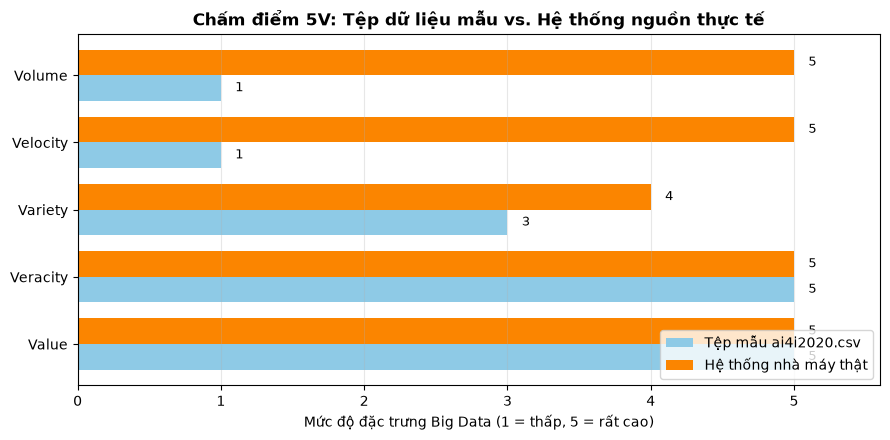

Nhận xét: khoảng cách giữa 2 thanh ở Volume và Velocity chính là khoảng cách giữa
'bài tập trên lớp' và 'hệ thống production' - cũng là lý do khóa học phải học tiếp Hadoop, Spark, Kafka.


In [8]:
# ============ TRỰC QUAN HÓA BẢNG CHẤM ĐIỂM 5V ============
import numpy as np
import matplotlib.pyplot as plt

dims         = ["Volume", "Velocity", "Variety", "Veracity", "Value"]
score_sample = [1, 1, 3, 5, 5]   # điểm 1-5: mức độ "Big Data" của TỆP MẪU ai4i2020.csv
score_real   = [5, 5, 4, 5, 5]   # điểm 1-5: mức độ "Big Data" của HỆ THỐNG NHÀ MÁY THẬT

y     = np.arange(len(dims))
height = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(y + height/2, score_sample, height, label="Tệp mẫu ai4i2020.csv", color="#8ecae6")
ax.barh(y - height/2, score_real,   height, label="Hệ thống nhà máy thật", color="#fb8500")

ax.set_yticks(y, dims)
ax.invert_yaxis()
ax.set_xlim(0, 5.6)
ax.set_xticks(range(6))
ax.set_xlabel("Mức độ đặc trưng Big Data (1 = thấp, 5 = rất cao)")
ax.set_title("Chấm điểm 5V: Tệp dữ liệu mẫu vs. Hệ thống nguồn thực tế", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

for yi, (s, r) in enumerate(zip(score_sample, score_real)):
    ax.text(s + 0.1, yi + height/2, str(s), va="center", fontsize=9)
    ax.text(r + 0.1, yi - height/2, str(r), va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Nhận xét: khoảng cách giữa 2 thanh ở Volume và Velocity chính là khoảng cách giữa")
print("'bài tập trên lớp' và 'hệ thống production' - cũng là lý do khóa học phải học tiếp Hadoop, Spark, Kafka.")

In [9]:
# ============ XUẤT BÁO CÁO TÓM TẮT report_lab01.md ============
# (Tiêu chí hoàn thành Bài 01: nộp file báo cáo tóm tắt phân tích 5V)
report = f"""# BÁO CÁO TÓM TẮT LAB 01 — PHÂN TÍCH 5V BIG DATA

**Bộ dữ liệu:** AI4I 2020 Predictive Maintenance (`ai4i2020.csv`)
**Bài toán:** Bảo trì dự đoán (Predictive Maintenance) cho máy móc nhà máy

## 1. Volume (Khối lượng)
- Tệp mẫu: {n_rows:,} dòng x {n_cols} cột, chiếm {mem_bytes/1024**2:.2f} MB trong RAM (~{bytes_per_row:.0f} bytes/dòng).
- Ngoại suy thực tế ({MACHINES} máy/nhà máy, lấy mẫu {SAMPLING_HZ} Hz): {rows_plant_day:,} dòng/ngày = {size_gb(rows_plant_day):.2f} GB/ngày.
- Quy mô {PLANTS} nhà máy: {size_gb(rows_corp_year)/1024:.2f} TB/năm -> vượt xa năng lực của một máy đơn.

## 2. Velocity (Tốc độ)
- Tệp mẫu: dữ liệu tĩnh, xử lý theo lô (batch).
- Hệ thống thật: {msg_per_sec:,} bản ghi/giây (~{mb_per_sec:.2f} MB/s), yêu cầu cảnh báo trong vài giây.

## 3. Variety (Đa dạng)
- 4 nhóm dữ liệu: định danh, phân loại (Type: L/M/H), cảm biến liên tục, nhãn nhị phân đa nhãn.
- Thực tế bổ sung: sóng rung, ảnh nhiệt, log JSON, phiếu bảo trì dạng văn bản.

## 4. Veracity (Độ tin cậy)
- Giá trị khuyết: {int(df_ai4i.isna().sum().sum())} | Dòng trùng lặp: {int(df_ai4i.duplicated().sum())}
- Mất cân bằng nhãn: {fail:,}/{n_rows:,} ca hỏng ({fail_rate*100:.2f}%).
- Mâu thuẫn nhãn: {conflict_no_cause} dòng hỏng không rõ nguyên nhân, {conflict_no_fail} dòng có nguyên nhân nhưng không tính là hỏng.
- Nhiễu ngẫu nhiên RNF: {rnf} ca ({rnf/n_rows*100:.2f}%) — giới hạn trần của mọi mô hình dự báo.

## 5. Value (Giá trị)
- Phát hiện sớm {DETECT_RATE:.0%} số ca hỏng => tiết kiệm ước tính {caught * saving_per_case:,.0f} VNĐ trên tệp mẫu.
- KPI đúng: Recall và F1-score (KHÔNG dùng Accuracy, vì mô hình ngây thơ đã đạt {naive_acc:.2%}).

## Kết luận
Xét riêng dung lượng, tệp mẫu chưa phải Big Data. Nhưng xét bản chất bài toán và hệ thống nguồn
sinh ra dữ liệu, đây là bài toán Big Data đầy đủ 5V — cần kiến trúc HDFS / Spark / Kafka khi triển khai thật.
"""

with open("report_lab01.md", "w", encoding="utf-8") as f:
    f.write(report)

print("Đã xuất báo cáo tóm tắt: report_lab01.md")
print("-" * 60)
print(report)

NameError: name 'DETECT_RATE' is not defined

### Giới thiệu cơ bản về Python cho Phân tích Dữ liệu

### 1. Python là gì? Tại sao chọn Python cho Big Data & AI?
* **Dễ học, dễ đọc**: Cú pháp gần gũi với tiếng Anh tự nhiên.
* **Hệ sinh thái thư viện phong phú**: `Pandas` (xử lý bảng), `NumPy` (tính toán ma trận), `Matplotlib/Seaborn` (trực quan hóa), `PySpark` (xử lý dữ liệu lớn).
* **Đặc trưng quan trọng**: Python sử dụng **thụt lề (Indentation)** bằng 4 khoảng trắng hoặc phím `Tab` để phân cấp các khối lệnh (thay vì dùng `{}` như C/C++/Java).

---

### 2. Các khái niệm lập trình cơ bản cần nắm vững
1. **Biến & Kiểu dữ liệu**: `int`, `float`, `str`, `bool`.
2. **Cấu trúc lưu trữ dữ liệu**: `List` (danh sách), `Dictionary` (từ điển key-value).
3. **Hàm (Functions)**: Tái sử dụng logic code.
4. **Thư viện (Libraries / Packages)**: Sử dụng từ khóa `import` để nạp các công cụ có sẵn.


In [10]:
# 1. Khai báo biến và các kiểu dữ liệu cơ bản
sensor_id = 101                    # int (Số nguyên)
temperature = 298.15               # float (Số thực - độ Kelvin)
machine_name = "Milling Machine"   # str (Chuỗi ký tự)
is_failed = False                  # bool (Đúng/Sai - True/False)

# In kết quả và kiểm tra kiểu dữ liệu bằng hàm type()
print(f"Máy: {machine_name}, Nhiệt độ: {temperature}K, Lỗi: {is_failed}")
print("Kiểu của temperature:", type(temperature))

Máy: Milling Machine, Nhiệt độ: 298.15K, Lỗi: False
Kiểu của temperature: <class 'float'>


In [11]:
sensor_id = 101
temperature = 298.15
print(f"Nhiệt độ: {temperature}K, Sensor ID: {sensor_id} ")

Nhiệt độ: 298.15K, Sensor ID: 101 


### 3. List và Dictionary trong Python
* **List `[]`**: Lưu danh sách các phần tử theo thứ tự, có thể truy xuất bằng chỉ số index (bắt đầu từ `0`).
* **Dictionary `{}`**: Lưu dữ liệu theo cặp `Key: Value`, là nền tảng để tạo ra các cột và dòng trong bảng dữ liệu (`Pandas DataFrame`).


In [12]:
# 1. List: Danh sách nhiệt độ ghi nhận được qua các lần đo
temp_records = [298.1, 298.2, 298.5, 300.1, 301.4]
print("Nhiệt độ đo lần đầu:", temp_records[0])
print("Tổng số lần ghi nhận:", len(temp_records))

# 2. Dictionary: Thông tin chi tiết của một bản ghi cảm biến máy
machine_record = {
    "UDI": 1,
    "Product_ID": "M14860",
    "Type": "M",
    "Air_temperature": 298.1,
    "Machine_failure": 0
}

print("Mã máy:", machine_record["Product_ID"])
print("Trạng thái hỏng hóc:", machine_record["Machine_failure"])

Nhiệt độ đo lần đầu: 298.1
Tổng số lần ghi nhận: 5
Mã máy: M14860
Trạng thái hỏng hóc: 0


### 4. Cấu trúc rẽ nhánh (`if - else`) & Vòng lặp (`for`)
* Dùng để kiểm tra điều kiện (ví dụ: cảnh báo khi nhiệt độ vượt ngưỡng an toàn).
* Dùng vòng lặp để duyệt qua từng phần tử dữ liệu.


In [13]:
# Kiểm tra ngưỡng nhiệt độ cảnh báo
threshold = 300.0  # Ngưỡng nhiệt độ an toàn (Kelvin)

for temp in temp_records:
    if temp > threshold:
        print(f"Cảnh báo: Nhiệt độ {temp}K vượt ngưỡng an toàn ({threshold}K)!")
    else:
        print(f"Bình thường: Nhiệt độ {temp}K nằm trong khoảng an toàn.")

Bình thường: Nhiệt độ 298.1K nằm trong khoảng an toàn.
Bình thường: Nhiệt độ 298.2K nằm trong khoảng an toàn.
Bình thường: Nhiệt độ 298.5K nằm trong khoảng an toàn.
Cảnh báo: Nhiệt độ 300.1K vượt ngưỡng an toàn (300.0K)!
Cảnh báo: Nhiệt độ 301.4K vượt ngưỡng an toàn (300.0K)!


### 5. Từ Dictionary/List sang Pandas DataFrame
Bảng dữ liệu `Pandas DataFrame` thực chất là sự kết hợp của nhiều `List` hoặc một danh sách các `Dictionary`.
Khi ta dùng lệnh `pd.read_csv("ai4i2020.csv")`, Pandas sẽ tự động đọc toàn bộ file CSV và chuyển hóa thành cấu trúc bảng nhiều dòng - nhiều cột.

In [14]:
import pandas as pd

# Mô phỏng dữ liệu thu nhỏ trước khi đọc toàn bộ file ai4i2020.csv
sample_data = {
    "UDI": [1, 2, 3],
    "Type": ["M", "L", "H"],
    "Air temperature [K]": [298.1, 298.2, 298.1],
    "Machine failure": [0, 0, 1]
}

df_sample = pd.DataFrame(sample_data)
df_sample

,UDI,Type,Air temperature [K],Machine failure
0,1,M,298.1,0
1,2,L,298.2,0
2,3,H,298.1,1


In [1]:
import os
import shutil
import kagglehub
import pandas as pd

# 1. file_path lưu dataset
target_dir = r"C:\Users\Admin\Desktop\Project\DataAnalytics\Lab1"
os.makedirs(target_dir, exist_ok=True) # Tự động tạo thư mục nếu chưa có

downloaded_path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")

# 3. Di chuyển dataset vừa tải về thư mục đích (target_dir)
filename = "predictive_maintenance_dataset_ai4i_2020.csv"
src_file = os.path.join(downloaded_path, filename)
dest_file = os.path.join(target_dir, filename)

# Nếu file chưa tồn tại ở thư mục đích, tiến hành sao chép sang
if os.path.exists(src_file):
    shutil.copy(src_file, dest_file)
    print(f"Đã tải và lưu file thành công tại: {dest_file}")
else:
    # Trường hợp Kaggle đổi tên file bên trong, ta sẽ quét tìm file .csv bất kỳ để di chuyển
    for file in os.listdir(downloaded_path):
        if file.endswith('.csv'):
            shutil.copy(os.path.join(downloaded_path, file), os.path.join(target_dir, file))
            dest_file = os.path.join(target_dir, file)
            print(f"Đã tải và lưu file thành công tại: {dest_file}")
            break

# 4. Đọc dữ liệu lên để làm bài tập thực hành
df = pd.read_csv(dest_file)
print("\n--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head())

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đã tải và lưu file thành công tại: C:\Users\Admin\Desktop\Project\DataAnalytics\Lab1\ai4i2020.csv

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Bài tập

### Làm quen với Python
*Mục tiêu*: Luyện tập biến, kiểu dữ liệu, danh sách (List), từ điển (Dictionary), vòng lặp, câu lệnh điều kiện và hàm xử lý dữ liệu trước khi thao tác trên tập dữ liệu thực tế.

*Bài tập 1*: Khởi tạo biến & Chuyển đổi đơn vị nhiệt độ
1. Khai báo 3 biến lưu thông số cảm biến của máy:
   - `machine_id`: Mã máy dạng chuỗi `"M14860"`
   - `air_temp_k`: Nhiệt độ không khí `298.2` (độ Kelvin)
   - `process_temp_k`: Nhiệt độ quy trình `308.7` (độ Kelvin)
2. Viết công thức tính độ chênh lệch nhiệt độ giữa quy trình và không khí: `temp_diff = process_temp_k - air_temp_k`
3. Chuyển đổi `air_temp_k` sang độ Celsius (°C) theo công thức: $C = K - 273.15$
4. In kết quả ra màn hình với định dạng làm tròn 2 chữ số thập phân.


In [ ]:
# --- BÀI TẬP 1: VIẾT CODE CỦA BẠN DƯỚI ĐÂY ---
# 1. Khai báo biến


# 2. Tính độ chênh lệch nhiệt độ


# 3. Đổi sang độ C


# 4. In kết quả
# Gợi ý: Dùng f-string: print(f"Nhiệt độ không khí: {temp_c:.2f}°C")


*Bài tập 2*: Cảnh báo lực xoắn (Torque) quá tải
Cho danh sách lực xoắn (Nm) của các máy:
`torques = [42.8, 46.3, 62.5, 39.5, 58.0, 71.2, 40.0]`

Biết rằng:
- Nếu Torque $\ge 60.0$ Nm: Máy bị *"Nguy cơ quá tải (Overstrain Risk)"*.
- Nếu $40.0 \le$ Torque $< 60.0$ Nm: Máy *"Hoạt động bình thường"*.
- Nếu Torque $< 40.0$ Nm: Máy *"Lực xoắn thấp"*.

*Yêu cầu:* Dùng vòng lặp `for` và `if-elif-else` để duyệt qua từng giá trị trong danh sách và in ra thông báo trạng thái tương ứng. Đếm xem có bao nhiêu máy có nguy cơ quá tải.


In [ ]:
# --- BÀI TẬP 3: VIẾT CODE CỦA BẠN DƯỚI ĐÂY ---
torques = [42.8, 46.3, 62.5, 39.5, 58.0, 71.2, 40.0]
overstrain_count = 0

# Viết vòng lặp for duyệt qua danh sách torques:


print(f"Tổng số máy có nguy cơ quá tải: {overstrain_count}")